# Diagramas de Persistencia y Distancias Wasserstein
**IDs 16 y 20** - Analisis topologico de la trayectoria emocional por sesion

Cada sesion (ID x dia) contiene 8 mediciones temporales de valence y arousal: `inicio -> p1_before -> p1_during -> p1_after -> p2_before -> p2_during -> p2_after -> final`

Estas 8 mediciones forman una nube de puntos 2D sobre la que se calcula el diagrama de persistencia de Rips. La **distancia Wasserstein** entre diagramas de dias consecutivos cuantifica cuanto cambio la estructura topologica de la respuesta emocional entre sesiones.

## 0. Dependencias

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from ripser import ripser
from persim import plot_diagrams, wasserstein

## 1. Carga de datos y creacion de `bebes_1620`

In [77]:
DATA_PATH = Path(
    r'C:\Users\Maria Paula\OneDrive\Documents\GitHub\Reto_Topo\DataFrameBabyFaceValidacion.csv'
)

MISSING_TOKENS = {'', '-', 'NA', 'NA ', 'N/A', 'nan', 'NaN',
                  'FIT_FAILED', 'FIT FAILED', 'FIND_FAILED', 'S/I', None}

def parse_numeric(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s in MISSING_TOKENS:
        return np.nan
    try:
        return float(s.replace(',', '.'))
    except Exception:
        return np.nan

def parse_day_number(x):
    """Extrae el numero de dia de etiquetas como 7E, 7P, 4.2."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    match = re.search(r'\d+(?:\.\d+)?', s)
    return float(match.group(0)) if match else np.nan

raw = pd.read_csv(DATA_PATH)
va_cols = [c for c in raw.columns if c.startswith('valence') or c.startswith('arousal')]
binary_struct_cols = ['rechaza', 'llora', 'toca', 'prueba', 'consume']

df = raw.copy()
for c in va_cols + binary_struct_cols:
    df[c] = df[c].apply(parse_numeric)
df['dia_num'] = df['dia'].apply(parse_day_number)

bebes_1620 = df[df['id'].isin(['ID16', 'ID17','ID18','ID19','ID20'])].copy().reset_index(drop=True)

# Si hay dos filas con el mismo (id, dia_num), conservar la de menos valores faltantes
_data_cols = va_cols + binary_struct_cols
bebes_1620['_n_missing'] = bebes_1620[_data_cols].isna().sum(axis=1)
_antes = len(bebes_1620)
bebes_1620 = (bebes_1620
    .sort_values('_n_missing')
    .drop_duplicates(subset=['id', 'dia_num'], keep='first')
    .drop(columns='_n_missing')
    .reset_index(drop=True))
_despues = len(bebes_1620)
if _antes > _despues:
    print(f'Deduplicacion: {_antes - _despues} fila(s) eliminada(s) por dia_num duplicado.')

print(f'bebes_1620: {bebes_1620.shape[0]} filas x {bebes_1620.shape[1]} columnas')
print(f"IDs: {bebes_1620['id'].unique().tolist()}")
print()
print('Dias disponibles por ID:')
print(bebes_1620.groupby('id')['dia'].apply(list).to_string())

Deduplicacion: 11 fila(s) eliminada(s) por dia_num duplicado.
bebes_1620: 71 filas x 28 columnas
IDs: ['ID19', 'ID18', 'ID17', 'ID20', 'ID16']

Dias disponibles por ID:
id
ID16    [2E, 8E, 14E, 19E, 11E, 4E, 13E, 18E, 16E, 12E...
ID17       [7P, 9P, 2P, 10P, 1E, 3P, 4P, 6P, 8P, 11P, 5P]
ID18                                [7, 2, 1, 3, 5, 4, 6]
ID19    [16E, 3E, 5E, 8E, 2E, 15E, 11E, 12E, 14E, 19E,...
ID20    [11, 5, 7, 8, 9, 10, 14, 15, 3, 2, 13, 4, 6, 1...


## 2. Definicion de columnas temporales

Cada fila tiene 8 momentos temporales dentro de la sesion:

| t | Momento | Valence col | Arousal col |
|---|---------|-------------|-------------|
| 0 | inicio | `valence_inicio` | `arousal_inicio` |
| 1 | p1 before | `valence_p1_before` | `arousal_p1_before` |
| 2 | p1 during | `valence_p1_during` | `arousal_p1_during` |
| 3 | p1 after | `valence_p1_after` | `arousal_p1_after` |
| 4 | p2 before | `valence_p2_before` | `arousal_p2_before` |
| 5 | p2 during | `valence_p2_during` | `arousal_p2_during` |
| 6 | p2 after | `valence_p2_after` | `arousal_p2_after` |
| 7 | final | `valence_final` | `arousal_final` |

**Nota sobre columnas binarias:** Los valores binarios (`rechaza`, `llora`, etc.) son constantes dentro de la sesion. Al aniadirlos como dimensiones extra, cada uno de los 8 puntos recibe el mismo valor en esa dimension. No cambia la topologia intra-sesion, pero **si afecta la distancia entre sesiones** cuando el valor cambia de un dia al siguiente.

In [78]:
VALENCE_COLS = [
    'valence_inicio',
    'valence_p1_before', 'valence_p1_during', 'valence_p1_after',
    'valence_p2_before', 'valence_p2_during', 'valence_p2_after',
    'valence_final',
]

AROUSAL_COLS = [
    'arousal_inicio',
    'arousal_p1_before', 'arousal_p1_during', 'arousal_p1_after',
    'arousal_p2_before', 'arousal_p2_during', 'arousal_p2_after',
    'arousal_final',
]

BINARY_COLS = ['rechaza', 'llora', 'toca', 'prueba', 'consume']

print('Columnas definidas.')
print(f'  Valence ({len(VALENCE_COLS)}): {VALENCE_COLS}')
print(f'  Arousal ({len(AROUSAL_COLS)}): {AROUSAL_COLS}')
print(f'  Binarias ({len(BINARY_COLS)}): {BINARY_COLS}')

Columnas definidas.
  Valence (8): ['valence_inicio', 'valence_p1_before', 'valence_p1_during', 'valence_p1_after', 'valence_p2_before', 'valence_p2_during', 'valence_p2_after', 'valence_final']
  Arousal (8): ['arousal_inicio', 'arousal_p1_before', 'arousal_p1_during', 'arousal_p1_after', 'arousal_p2_before', 'arousal_p2_during', 'arousal_p2_after', 'arousal_final']
  Binarias (5): ['rechaza', 'llora', 'toca', 'prueba', 'consume']


## 3. Funciones principales

In [79]:
def build_point_cloud(row, col_groups, binary_cols=None, normalize=True):
    """
    Construye la nube de puntos de una sesion (una fila del dataframe).

    Parametros
    ----------
    row : pd.Series  -- Fila del dataframe (una sesion ID x dia).
    col_groups : list[list[str]]
        Grupos de columnas temporales del mismo largo (= pasos temporales).
        Cada grupo agrega una dimension. Ej: [VALENCE_COLS, AROUSAL_COLS] -> nube 2D con 8 puntos.
    binary_cols : list[str] | None
        Columnas binarias anadidas como dimensiones constantes a cada punto.
    normalize : bool  -- Aplica MinMaxScaler por columna si True.

    Devuelve
    --------
    np.ndarray (n_puntos_validos, n_dimensiones) o None si quedan < 2 puntos.
    """
    n_steps = len(col_groups[0])
    if not all(len(g) == n_steps for g in col_groups):
        raise ValueError('Todos los col_groups deben tener el mismo numero de columnas.')

    # Matriz (n_steps x n_groups): cada fila es un instante temporal
    matrix = np.column_stack([row[g].values.astype(float) for g in col_groups])

    # Columnas binarias: misma dimension constante en cada paso temporal
    if binary_cols:
        binary_vals = np.array([float(row[c]) if pd.notna(row[c]) else np.nan
                                for c in binary_cols])
        binary_block = np.tile(binary_vals, (n_steps, 1))
        matrix = np.hstack([matrix, binary_block])

    # Descartar instantes con algun NaN
    valid_mask = ~np.isnan(matrix).any(axis=1)
    cloud = matrix[valid_mask]

    if cloud.shape[0] < 2:
        return None

    if normalize:
        scaler = MinMaxScaler()
        cloud = scaler.fit_transform(cloud)

    return cloud

In [80]:
def compute_persistence(point_cloud, max_dim=1):
    """
    Calcula el diagrama de persistencia de Rips para una nube de puntos.

    Parametros
    ----------
    point_cloud : np.ndarray (n, d)
    max_dim : int  -- 0=componentes conexas, 1=ciclos.

    Devuelve
    --------
    dict con claves 'dgms' (diagramas por dimension) y 'point_cloud'.
    """
    result = ripser(point_cloud, maxdim=max_dim)
    result['point_cloud'] = point_cloud
    return result

In [81]:
def generate_persistence_diagrams(
    df,
    col_groups,
    binary_cols=None,
    id_col='id',
    day_col='dia',
    day_num_col='dia_num',
    filter_ids=None,
    filter_days=None,
    max_dim=1,
    normalize=True,
    plot=True,
):
    """
    Genera diagramas de persistencia para cada sesion (ID x dia) del dataframe.

    Input
    -----
    df : pd.DataFrame  -- una fila por sesion.
    col_groups : list[list[str]]  -- grupos de columnas temporales.
    binary_cols : list[str] | None  -- columnas binarias opcionales.
    filter_ids, filter_days : list | None  -- filtros opcionales.
    max_dim : int  -- dimension homologica maxima para ripser.
    normalize, plot : bool.

    Output
    ------
    dict : {(id_val, dia_num): ripser_result}
    """
    subset = df.copy()
    if filter_ids is not None:
        subset = subset[subset[id_col].isin(filter_ids)]
    if filter_days is not None:
        subset = subset[subset[day_num_col].isin(filter_days)]

    diagrams = {}
    skipped = []

    for _, row in subset.iterrows():
        id_val = row[id_col]
        dia_label = row[day_col]
        dia_num = row[day_num_col]
        cloud = build_point_cloud(row, col_groups, binary_cols=binary_cols, normalize=normalize)
        if cloud is None:
            skipped.append((id_val, dia_label))
            continue
        result = compute_persistence(cloud, max_dim=max_dim)
        diagrams[(id_val, dia_num)] = result

    if skipped:
        print(f'Sesiones omitidas (< 2 puntos validos): {skipped}')
    print(f'Diagramas generados: {len(diagrams)}')

    if plot and diagrams:
        ids_in_result = sorted(set(k[0] for k in diagrams))
        for id_val in ids_in_result:
            id_keys = sorted([k for k in diagrams if k[0] == id_val], key=lambda x: x[1])
            n_days = len(id_keys)
            ncols = min(4, n_days)
            nrows = (n_days + ncols - 1) // ncols
            fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
            axes_flat = np.array(axes).flatten()
            fig.suptitle(f'Diagramas de Persistencia -- {id_val}', fontsize=13, fontweight='bold')
            for ax_idx, key in enumerate(id_keys):
                plot_diagrams(diagrams[key]['dgms'], show=False, ax=axes_flat[ax_idx])
                axes_flat[ax_idx].set_title(f'Dia {key[1]}', fontsize=10)
            for ax_idx in range(len(id_keys), len(axes_flat)):
                axes_flat[ax_idx].set_visible(False)
            plt.tight_layout()
            plt.show()
            print(f'Figura guardada: persistence_{id_val}.png')

    return diagrams

In [82]:
def wasserstein_between_consecutive_days(diagrams_dict, id_val, homology_dim=1):
    """
    Calcula la distancia Wasserstein entre diagramas de dias consecutivos para un ID.

    Parametros
    ----------
    diagrams_dict : dict  -- salida de generate_persistence_diagrams.
    id_val : str  -- ID a analizar (ej. 'ID16').
    homology_dim : int  -- 0=H0 (componentes), 1=H1 (ciclos).

    Devuelve
    --------
    pd.Series con indice 'dia_k -> dia_k+1' y valores de distancia Wasserstein.
    """
    id_keys = sorted([k for k in diagrams_dict if k[0] == id_val], key=lambda x: x[1])

    if len(id_keys) < 2:
        print(f'  {id_val}: menos de 2 dias con diagrama valido.')
        return pd.Series(dtype=float)

    def finite_dgm(dgm):
        return dgm[np.isfinite(dgm[:, 1])] if len(dgm) > 0 else np.empty((0, 2))

    distances = {}
    for i in range(len(id_keys) - 1):
        key_a, key_b = id_keys[i], id_keys[i + 1]
        dgm_a = finite_dgm(diagrams_dict[key_a]['dgms'][homology_dim])
        dgm_b = finite_dgm(diagrams_dict[key_b]['dgms'][homology_dim])
        dist = 0.0 if (len(dgm_a) == 0 and len(dgm_b) == 0) else wasserstein(dgm_a, dgm_b)
        distances[f'dia {key_a[1]} -> {key_b[1]}'] = dist

    return pd.Series(distances, name=f'W_H{homology_dim}_{id_val}')

In [83]:
def plot_wasserstein_progress(distances_dict, homology_dim=1, figsize=(12, 5)):
    """
    Visualiza la distancia Wasserstein entre dias consecutivos para cada ID.

    Parametros
    ----------
    distances_dict : dict  -- {id_val: pd.Series}.
    homology_dim : int  -- dimension usada (para el titulo).
    """
    fig, ax = plt.subplots(figsize=figsize)
    colors = plt.cm.tab10.colors

    def parse_transition(label):
        nums = re.findall(r'[\d.]+', label)
        return float(nums[0]), float(nums[1])

    for idx, (id_val, series) in enumerate(distances_dict.items()):
        if series.empty:
            continue
        color = colors[idx % len(colors)]

        transitions = [parse_transition(lbl) for lbl in series.index]
        x_pos = [(a + b) / 2 for a, b in transitions]
        y_vals = series.values

        # Conectar con linea solo si ambas transiciones adyacentes tienen span == 1
        segments = []
        cur_x = [x_pos[0]]
        cur_y = [y_vals[0]]
        for i in range(1, len(transitions)):
            span_prev = transitions[i - 1][1] - transitions[i - 1][0]
            span_curr = transitions[i][1] - transitions[i][0]
            if span_prev == 1 and span_curr == 1:
                cur_x.append(x_pos[i])
                cur_y.append(y_vals[i])
            else:
                segments.append((cur_x, cur_y))
                cur_x = [x_pos[i]]
                cur_y = [y_vals[i]]
        segments.append((cur_x, cur_y))

        for seg_idx, (sx, sy) in enumerate(segments):
            ax.plot(sx, sy, marker='o',
                    label=id_val if seg_idx == 0 else '_nolegend_',
                    color=color, linewidth=2, markersize=7)

        for xi, val in zip(x_pos, y_vals):
            ax.annotate(f'{val:.3f}', (xi, val),
                        textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=8, color=color)

    ax.set_title(f'Distancia Wasserstein H{homology_dim} entre dias consecutivos',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Dia (punto medio de la transicion)')
    ax.set_ylabel(f'Distancia Wasserstein (H{homology_dim})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'wasserstein_progress_H{homology_dim}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: wasserstein_progress_H{homology_dim}.png')

## 4. Ejecucion: IDs 16 y 20

### 4.1 Diagramas de persistencia (valence + arousal, sin binarias)

Sesiones omitidas (< 2 puntos validos): [('ID20', '1'), ('ID20', '12'), ('ID19', '13')]
Diagramas generados: 68


c:\Users\Maria Paula\AppData\Local\Programs\Python\Python313\Lib\site-packages\ripser\ripser.py:251: UserWarning: The input matrix is square, but the distance_matrix flag is off.  Did you mean to indicate that this was a distance matrix?
  warnings.warn(
c:\Users\Maria Paula\AppData\Local\Programs\Python\Python313\Lib\site-packages\ripser\ripser.py:251: UserWarning: The input matrix is square, but the distance_matrix flag is off.  Did you mean to indicate that this was a distance matrix?
  warnings.warn(
c:\Users\Maria Paula\AppData\Local\Programs\Python\Python313\Lib\site-packages\ripser\ripser.py:251: UserWarning: The input matrix is square, but the distance_matrix flag is off.  Did you mean to indicate that this was a distance matrix?
  warnings.warn(
c:\Users\Maria Paula\AppData\Local\Programs\Python\Python313\Lib\site-packages\ripser\ripser.py:251: UserWarning: The input matrix is square, but the distance_matrix flag is off.  Did you mean to indicate that this was a distance matri

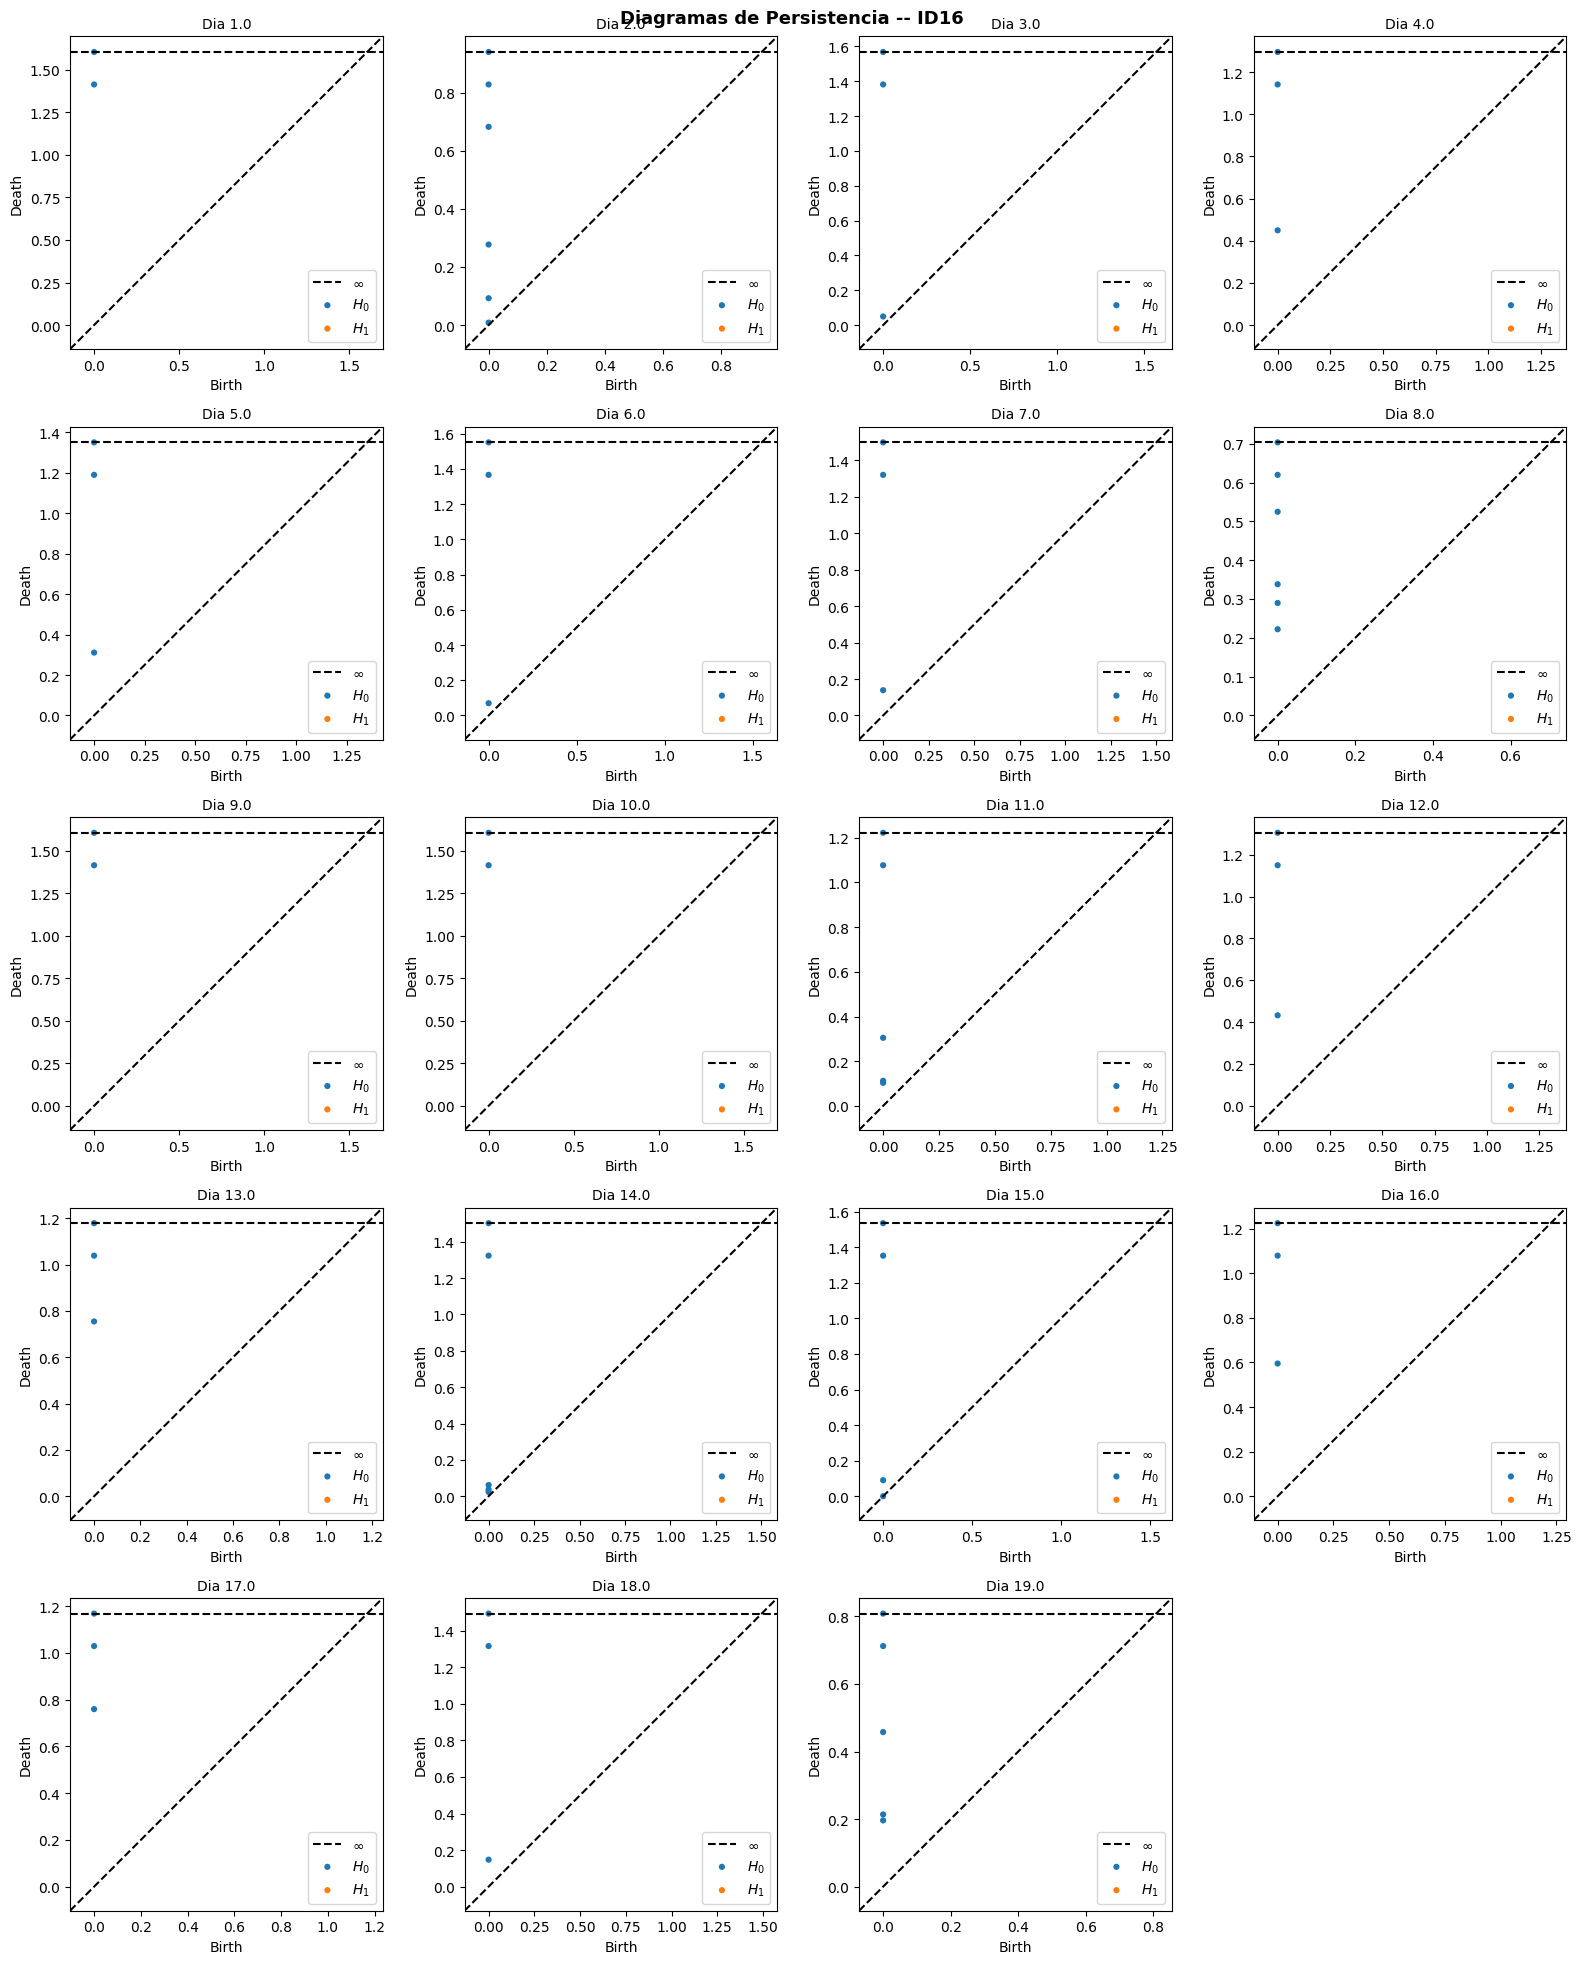

Figura guardada: persistence_ID16.png


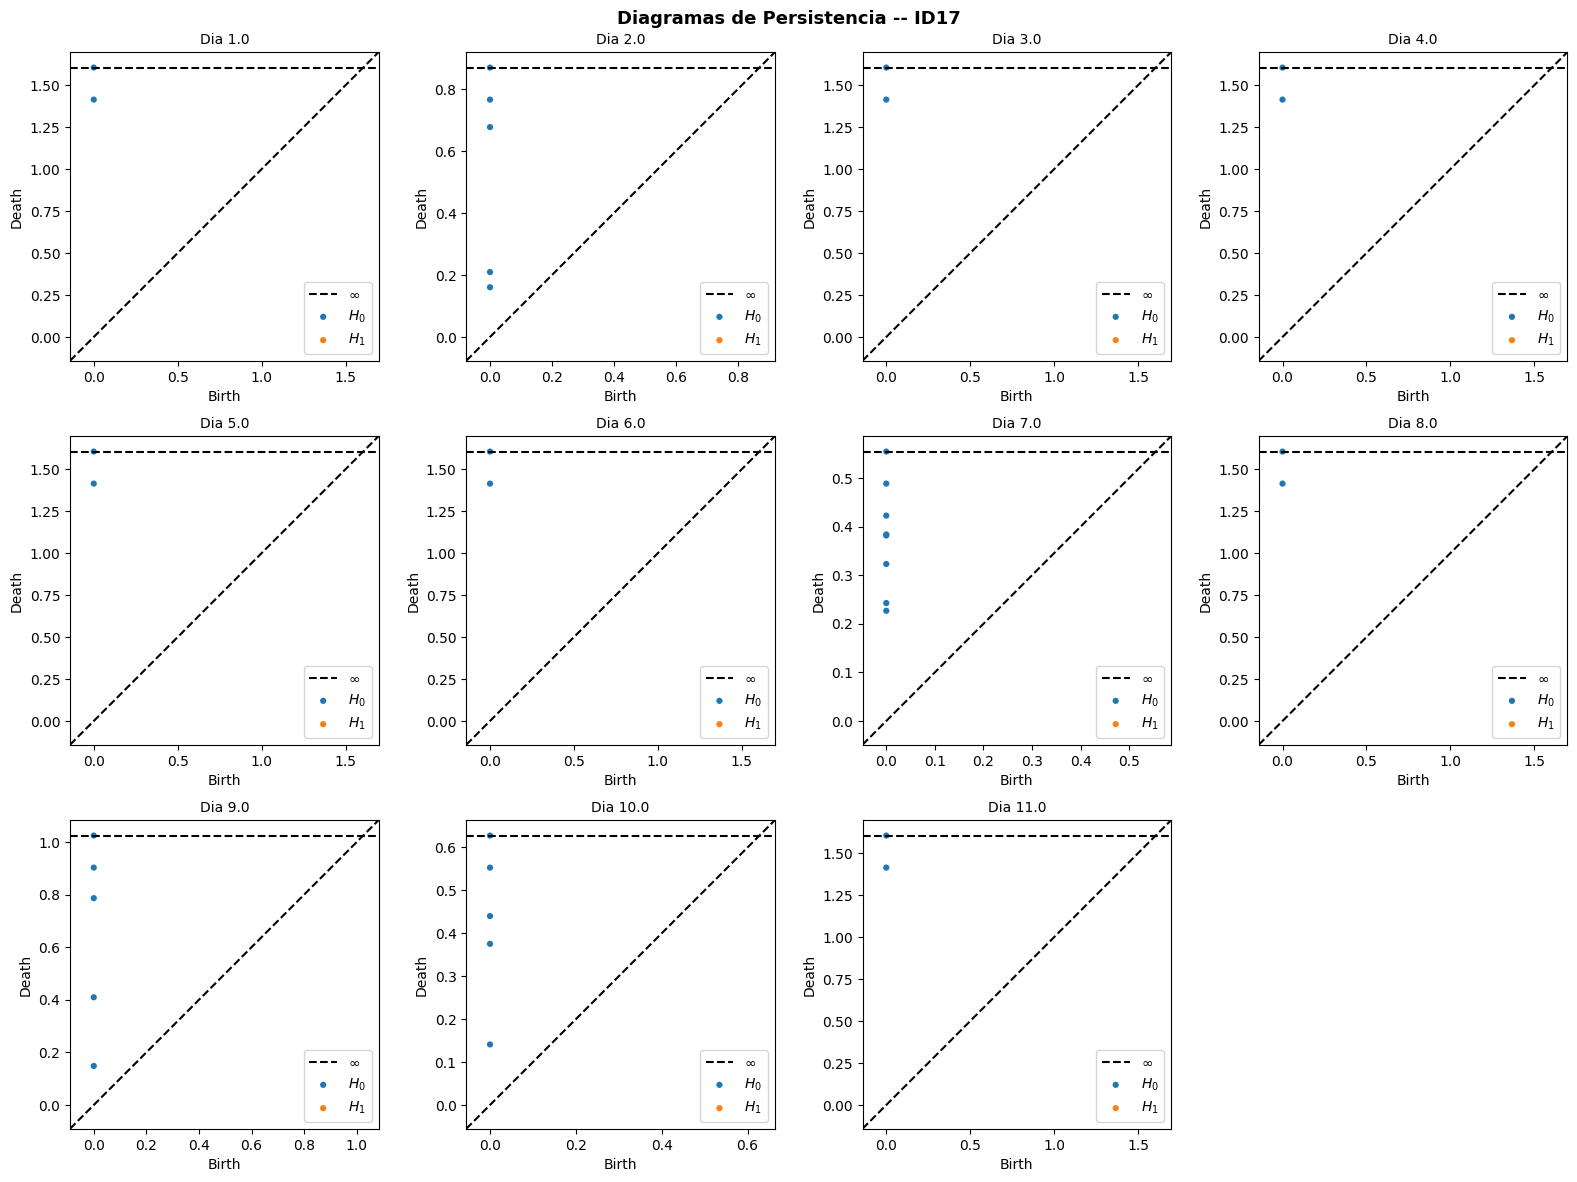

Figura guardada: persistence_ID17.png


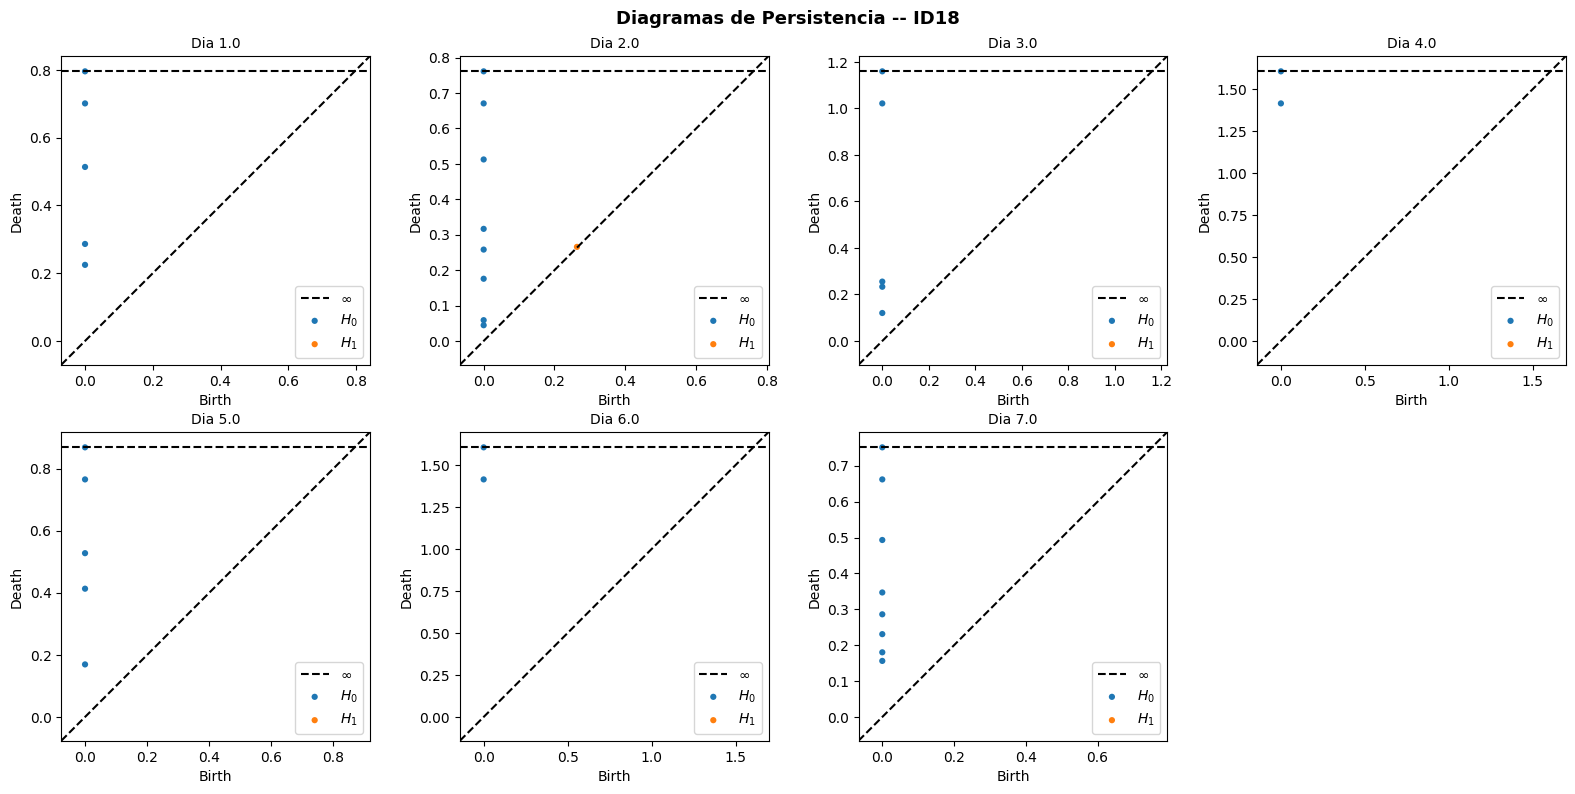

Figura guardada: persistence_ID18.png


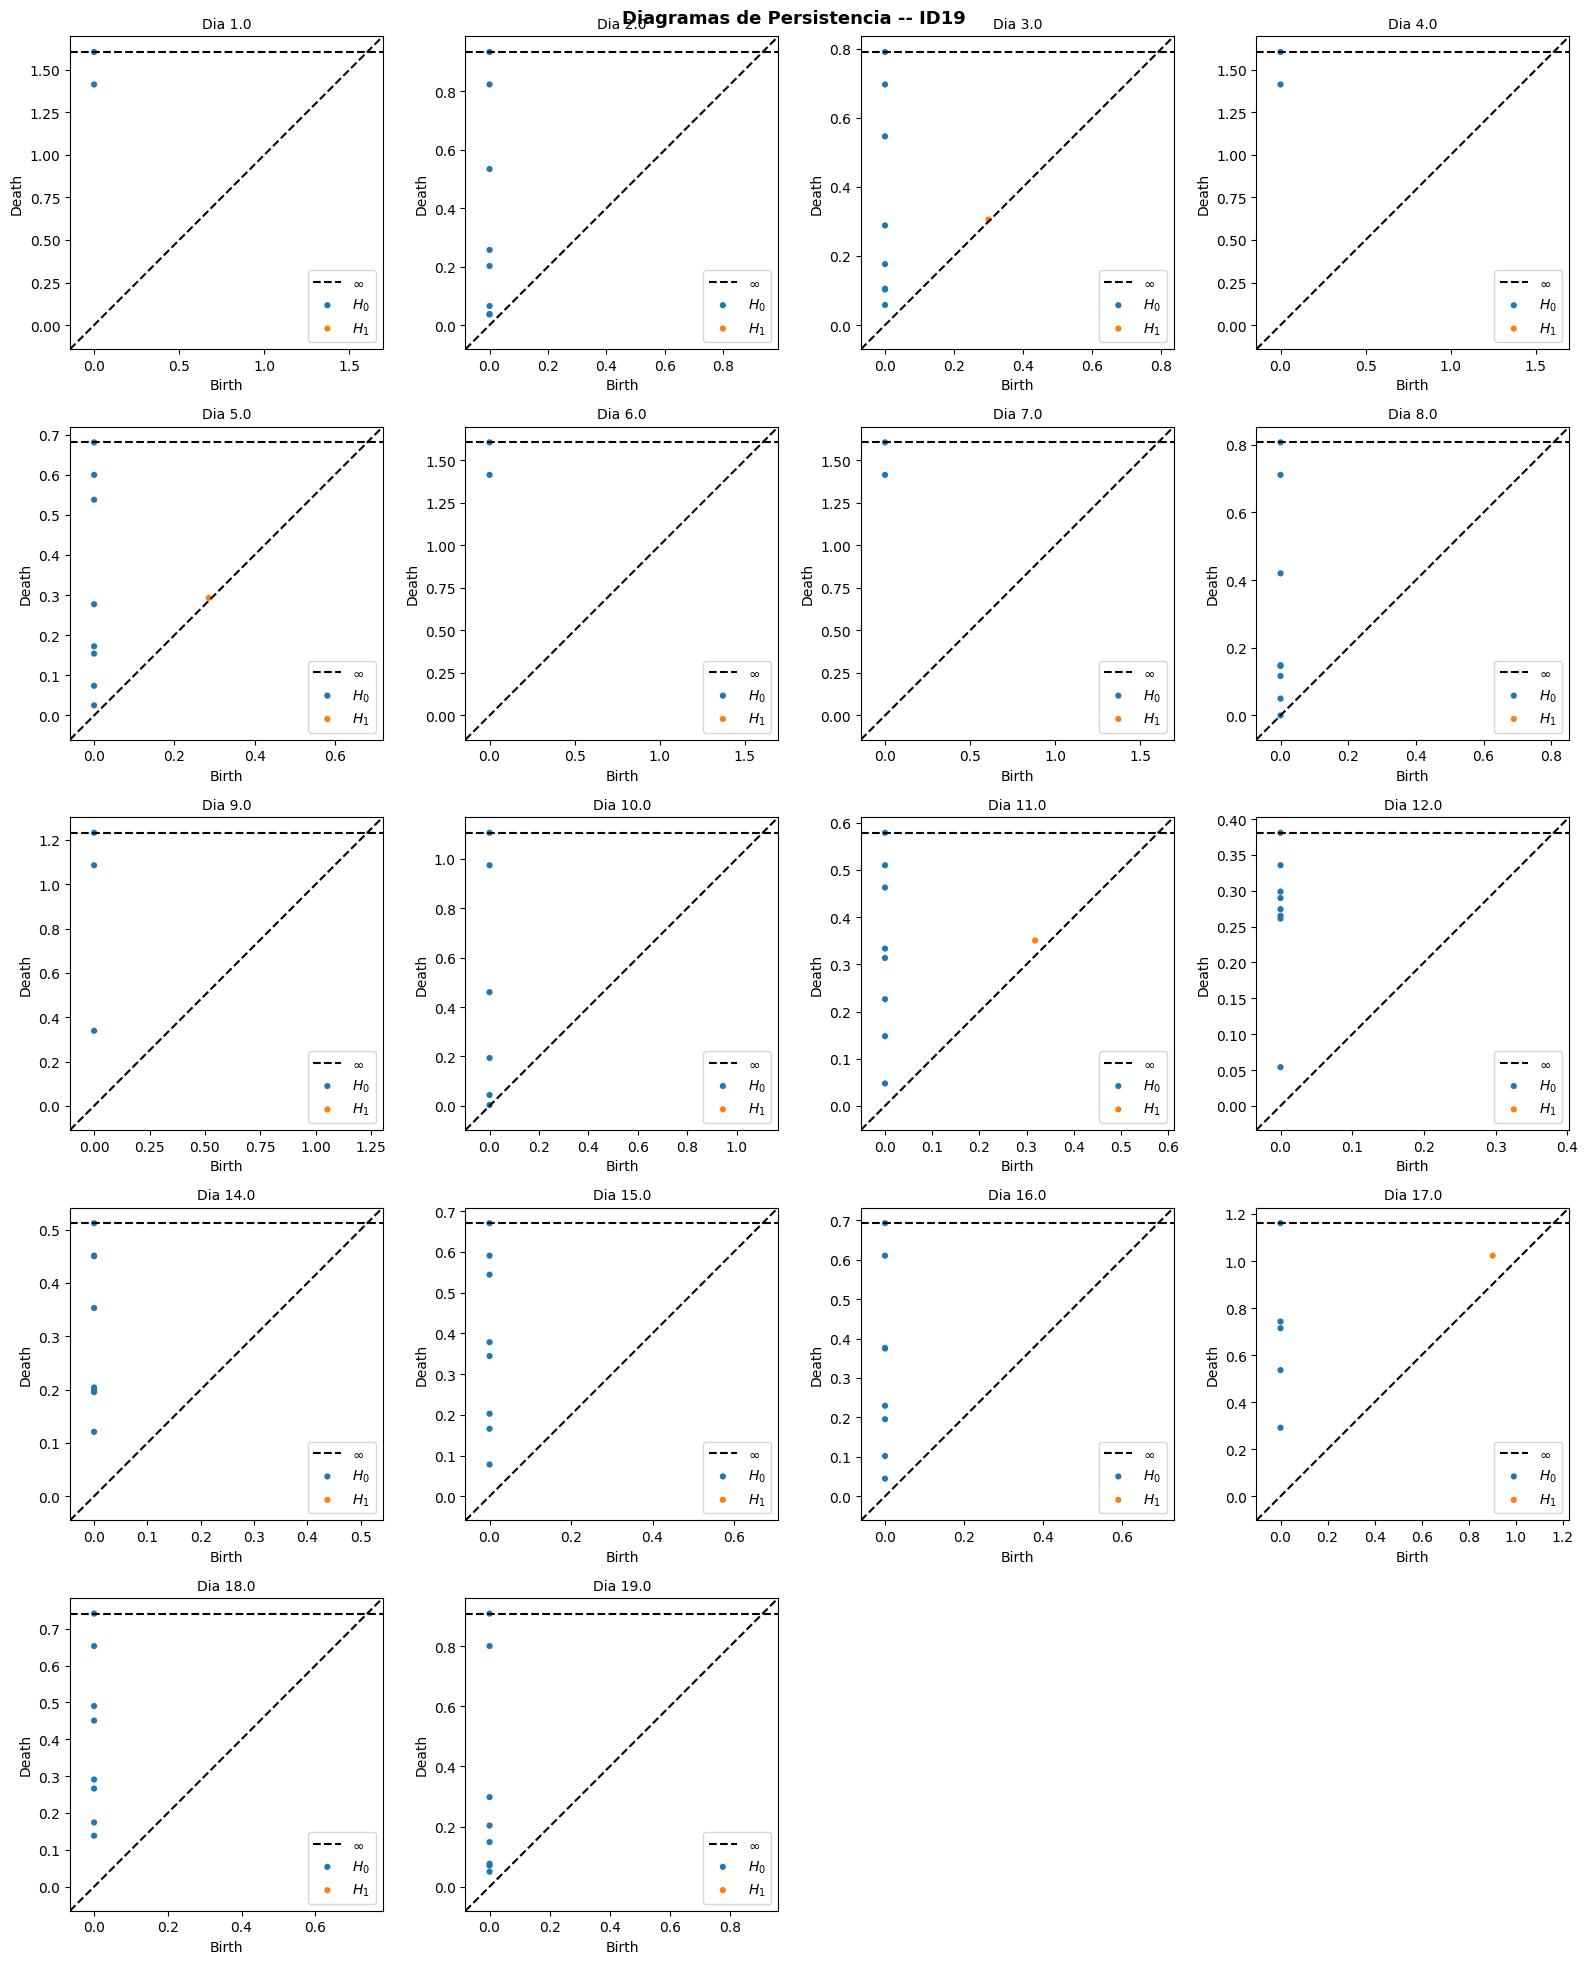

Figura guardada: persistence_ID19.png


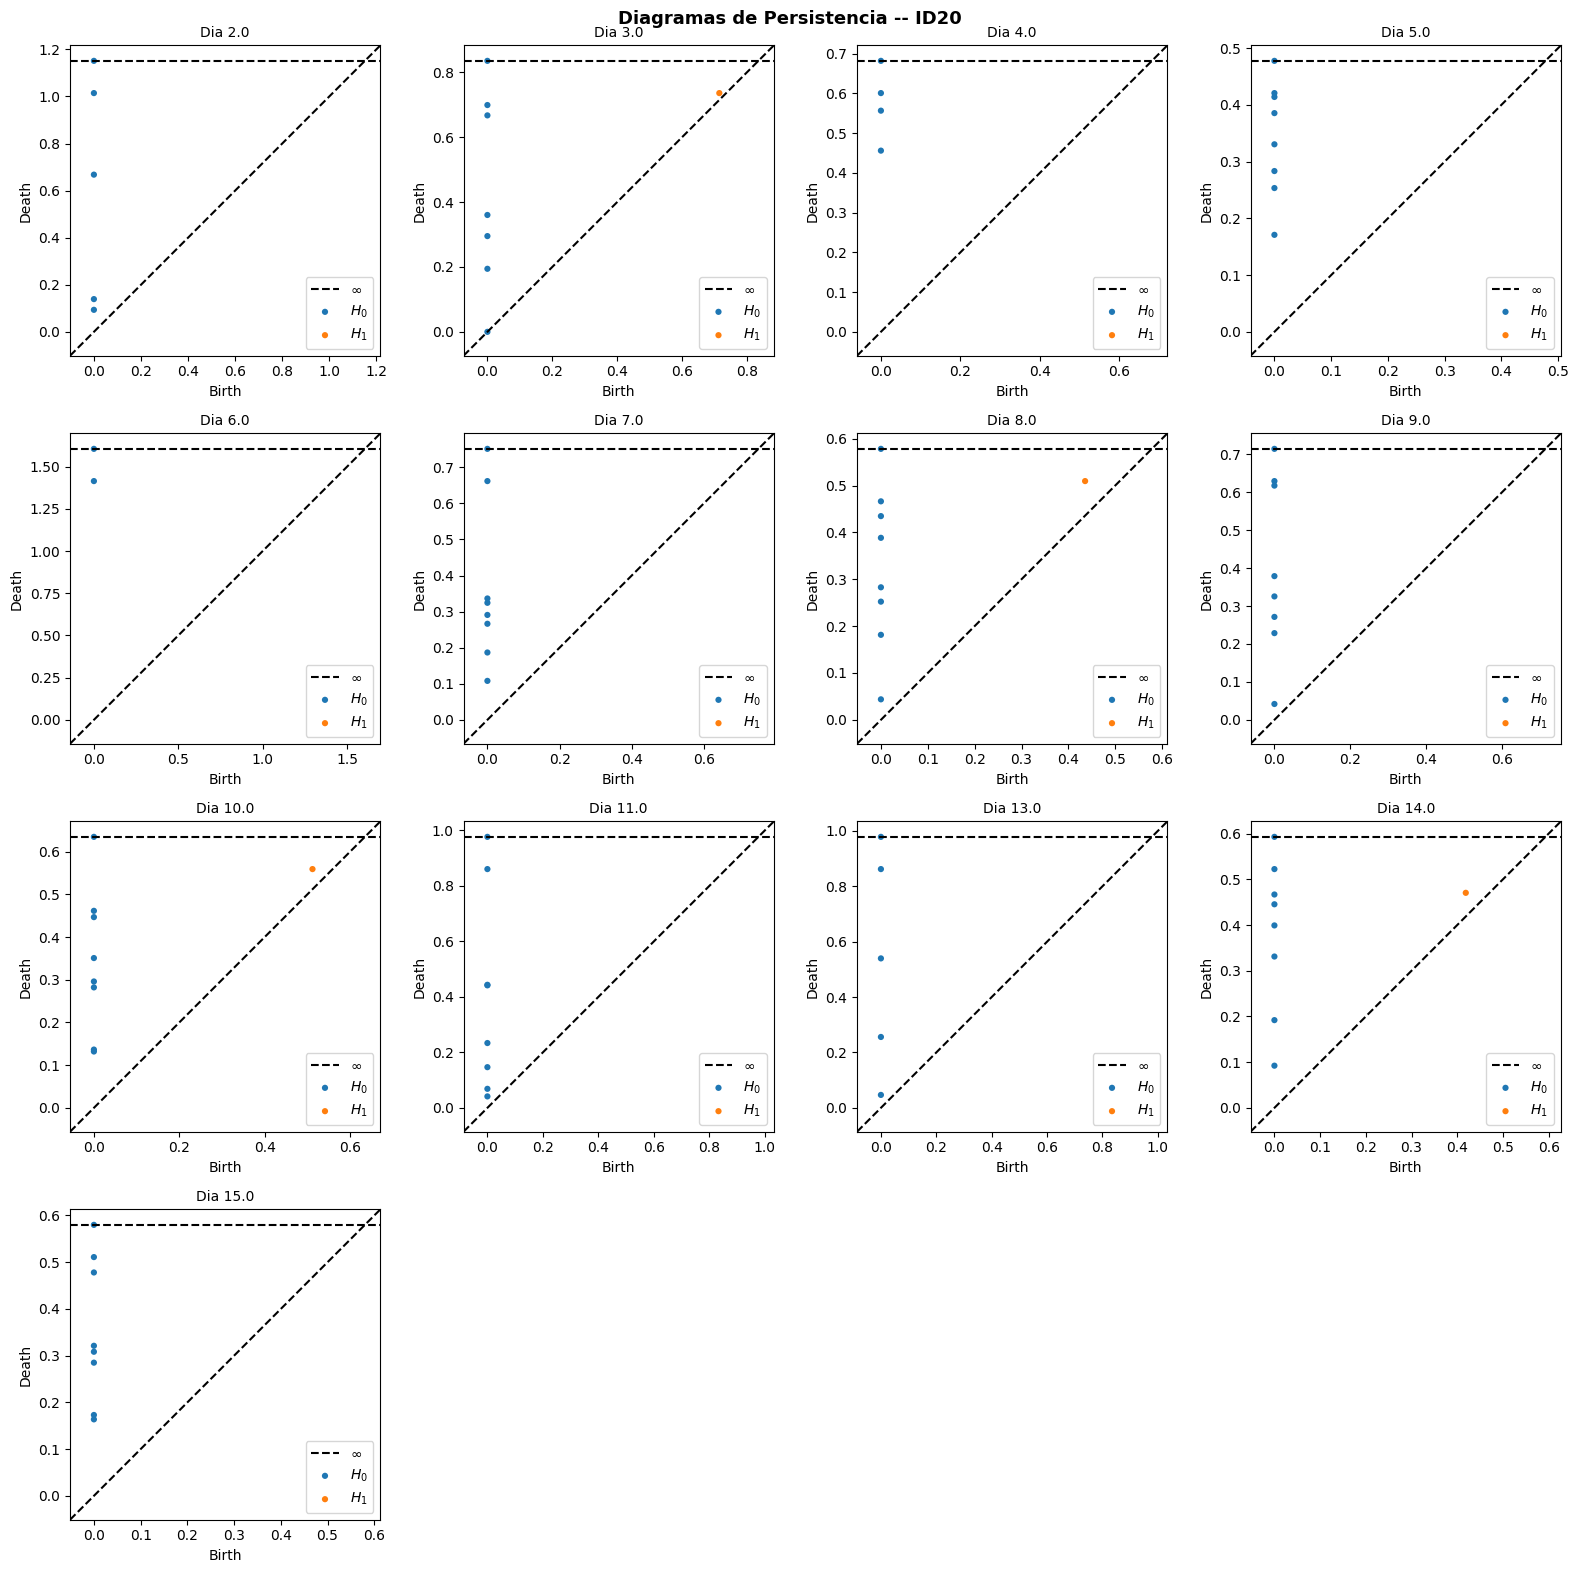

Figura guardada: persistence_ID20.png


In [84]:
diagrams = generate_persistence_diagrams(
    bebes_1620,
    col_groups=[VALENCE_COLS, AROUSAL_COLS],
    binary_cols=None,
    filter_ids=['ID16','ID17','ID18','ID19','ID20'],
    max_dim=1,
    normalize=True,
    plot=True,
)

### 4.2 Diagramas con columnas binarias (nube 7D: 2 continuas + 5 constantes por sesion)

In [85]:
diagrams_with_binary = generate_persistence_diagrams(
    bebes_1620,
    col_groups=[VALENCE_COLS, AROUSAL_COLS],
    binary_cols=BINARY_COLS,
    filter_ids=['ID16','ID17','ID18','ID19','ID20'],
    max_dim=1,
    normalize=True,
    plot=False,
)
print(f'Diagramas con binarias: {len(diagrams_with_binary)}')
print('Claves ejemplo:', list(diagrams_with_binary.keys())[:5])

Sesiones omitidas (< 2 puntos validos): [('ID20', '1'), ('ID20', '12'), ('ID19', '13')]
Diagramas generados: 68
Diagramas con binarias: 68
Claves ejemplo: [('ID19', 16.0), ('ID19', 3.0), ('ID19', 5.0), ('ID19', 8.0), ('ID19', 2.0)]


c:\Users\Maria Paula\AppData\Local\Programs\Python\Python313\Lib\site-packages\ripser\ripser.py:251: UserWarning: The input matrix is square, but the distance_matrix flag is off.  Did you mean to indicate that this was a distance matrix?
  warnings.warn(
c:\Users\Maria Paula\AppData\Local\Programs\Python\Python313\Lib\site-packages\ripser\ripser.py:251: UserWarning: The input matrix is square, but the distance_matrix flag is off.  Did you mean to indicate that this was a distance matrix?
  warnings.warn(
c:\Users\Maria Paula\AppData\Local\Programs\Python\Python313\Lib\site-packages\ripser\ripser.py:251: UserWarning: The input matrix is square, but the distance_matrix flag is off.  Did you mean to indicate that this was a distance matrix?
  warnings.warn(
c:\Users\Maria Paula\AppData\Local\Programs\Python\Python313\Lib\site-packages\ripser\ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\Maria Paula\AppDat

### 4.3 Distancias Wasserstein entre dias consecutivos

In [86]:
all_distances_H1 = {}
for id_val in ['ID16','ID17','ID18','ID19','ID20']: 
    series = wasserstein_between_consecutive_days(diagrams, id_val, homology_dim=1)
    all_distances_H1[id_val] = series

In [87]:
all_distances_H0 = {}
for id_val in ['ID16','ID17','ID18','ID19','ID20']:
    series = wasserstein_between_consecutive_days(diagrams, id_val, homology_dim=0)
    all_distances_H0[id_val] = series

### 4.4 Visualizacion del progreso

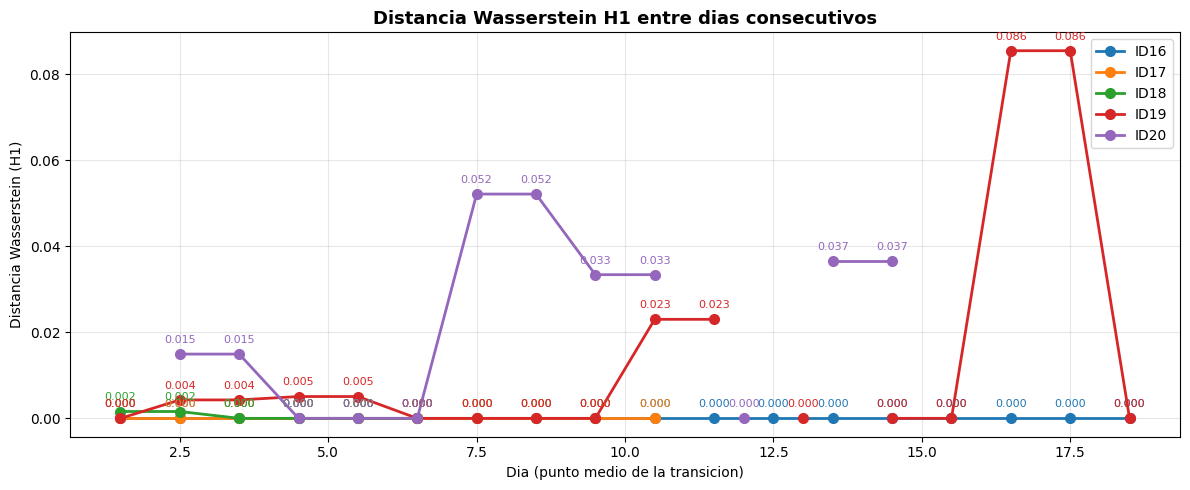

Figura guardada: wasserstein_progress_H1.png


In [88]:
plot_wasserstein_progress(all_distances_H1, homology_dim=1)

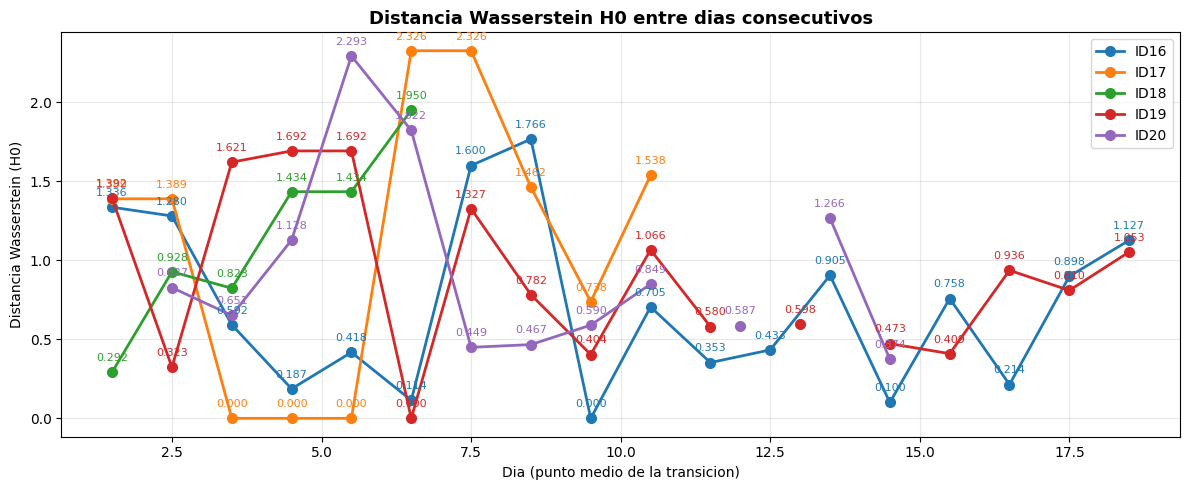

Figura guardada: wasserstein_progress_H0.png


In [89]:
plot_wasserstein_progress(all_distances_H0, homology_dim=0)

### 4.5 Tabla resumen

In [95]:
rows = []
for id_val in ['ID16','ID17','ID18','ID19', 'ID20']:
    h0 = all_distances_H0.get(id_val, pd.Series(dtype=float))
    h1 = all_distances_H1.get(id_val, pd.Series(dtype=float))
    for t in sorted(set(h0.index) | set(h1.index)):
        rows.append({'id': id_val, 'transicion': t,
                     'W_H0': h0.get(t, np.nan), 'W_H1': h1.get(t, np.nan)})
df_wasserstein = pd.DataFrame(rows)
print(f'Total transiciones: {len(df_wasserstein)}')
df_wasserstein

Total transiciones: 63


,id,transicion,W_H0,W_H1
0,ID16,dia 1.0 -> 2.0,1.335758,0.000000
1,ID16,dia 10.0 -> 11.0,0.704807,0.000000
2,ID16,dia 11.0 -> 12.0,0.352942,0.000000
3,ID16,dia 12.0 -> 13.0,0.432984,0.000000
4,ID16,dia 13.0 -> 14.0,0.905090,0.000000
...,...,...,...,...
58,ID20,dia 5.0 -> 6.0,2.292526,0.000000
59,ID20,dia 6.0 -> 7.0,1.821986,0.000000
60,ID20,dia 7.0 -> 8.0,0.449322,0.052169
61,ID20,dia 8.0 -> 9.0,0.466603,0.052169
